In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Загрузка исторических данных

name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
# name = "BTCUSDT_1h_10_years"
# filename = f"data/1h_10_years/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
# data = data['2025-03-29 06:00:00':]
data.drop(['high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

In [9]:
# Стратегия

short_window = 68
long_window = 41

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки
data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

In [10]:

def test(buy_size = 0.6,
         lot_size = 0.0001,
         initial_capital = 100000,
         commission_rate = 0.001):

    portfolio = pd.DataFrame(data=data[['signal', 'open']], index=data.index)
    portfolio['returns'] = data['open'].pct_change()

    portfolio['position_change'] = 0.0
    portfolio.loc[portfolio['signal'].shift(1).fillna(0) == 1, 'position_change'] = buy_size
    portfolio.loc[portfolio['signal'].shift(1).fillna(0) == -1, 'position_change'] = -buy_size

    portfolio['position'] = portfolio['position_change'].cumsum()
    portfolio['position'] = portfolio['position'].clip(0, 1)

    portfolio['commission'] = portfolio['position_change'].abs() * (commission_rate)

    portfolio['strategy_returns'] = (
        portfolio['position'].shift(1) * portfolio['returns']
        - portfolio['commission']
    )

    portfolio['equity'] = initial_capital * (1 + portfolio['strategy_returns']).cumprod()

    # желаемая позиция в деньгах
    portfolio['target_value'] = portfolio['equity'] * portfolio['position']
    # переводим в количество лотов
    portfolio['shares'] = np.floor(portfolio['target_value'] / portfolio['open'] / lot_size) * lot_size
    # обратно в долю
    portfolio['position_discrete'] = (portfolio['shares'] * portfolio['open']) / portfolio['equity']
    return portfolio


buy_size = 0.6
lot_size = 0.0001
initial_capital = 100000
commission_rate = 0.001
portfolio1 = test(buy_size, lot_size, initial_capital, commission_rate)

portfolio1['2025-04-06': '2025-09-15'].head(20)
portfolio1['2025-07-23': '2025-08-15'].head(60)
portfolio1.tail(20)

,signal,open,returns,position_change,position,commission,strategy_returns,equity,target_value,shares,position_discrete
timestamp,,,,,,,,,,,
2026-03-11 02:00:00,0,70071.26,0.000377,0.0,0.0,0.0,0.0,93051.078852,0.0,0.0,0.0
2026-03-11 03:00:00,0,69810.73,-0.003718,0.0,0.0,0.0,-0.0,93051.078852,0.0,0.0,0.0
2026-03-11 04:00:00,0,69551.91,-0.003707,0.0,0.0,0.0,-0.0,93051.078852,0.0,0.0,0.0
2026-03-11 05:00:00,0,70130.99,0.008326,0.0,0.0,0.0,0.0,93051.078852,0.0,0.0,0.0
2026-03-11 06:00:00,0,69510.37,-0.008849,0.0,0.0,0.0,-0.0,93051.078852,0.0,0.0,0.0
2026-03-11 07:00:00,0,69950.01,0.006325,0.0,0.0,0.0,0.0,93051.078852,0.0,0.0,0.0
2026-03-11 08:00:00,0,69648.28,-0.004314,0.0,0.0,0.0,-0.0,93051.078852,0.0,0.0,0.0
2026-03-11 09:00:00,0,69662.24,0.000200,0.0,0.0,0.0,0.0,93051.078852,0.0,0.0,0.0
2026-03-11 10:00:00,0,69466.75,-0.002806,0.0,0.0,0.0,-0.0,93051.078852,0.0,0.0,0.0


In [11]:
import time

start_time = time.perf_counter()  # или time.time()
portfolio1 = test(buy_size, lot_size, initial_capital, commission_rate)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")

Время выполнения: 0.007374 секунд


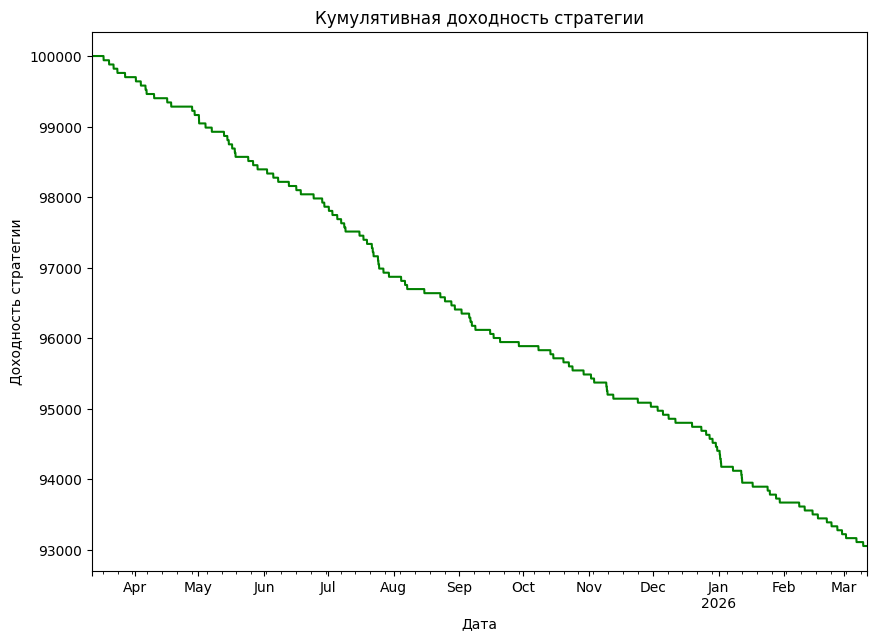

In [12]:
equity = initial_capital * (1 + portfolio1['strategy_returns']).cumprod()
equity.plot(figsize=(10, 7), color='green')
plt.title('Кумулятивная доходность стратегии')
plt.xlabel('Дата')
plt.ylabel('Доходность стратегии')
plt.show()

In [48]:
def test2(buy_size = 0.6,
         lot_size = 0.0001,
         initial_capital = 100000,
         commission_rate = 0.001):

    n = len(data)

    # 1. Массивы для хранения результатов
    returns = np.empty(n, dtype=np.float64)
    position_change = np.empty(n, dtype=np.float64)
    position = np.empty(n, dtype=np.float64)
    commission = np.empty(n, dtype=np.float64)
    strategy_returns = np.empty(n, dtype=np.float64)
    equity = np.empty(n, dtype=np.float64)
    target_value = np.empty(n, dtype=np.float64)
    shares = np.empty(n, dtype=np.float64)
    position_discrete = np.empty(n, dtype=np.float64)

    # 2. Расчёт доходности (векторизованно)
    returns[1:] = np.diff(data['open']) / data['open'][:-1]
    returns[0] = 0.0

    # 3. Расчёт изменения позиции (сдвиг сигнала на 1 шаг назад)
    signal_shifted = np.roll(data['signal'], 1)
    signal_shifted[0] = 0.0

    position_change = np.where(signal_shifted == 1, buy_size,
                               np.where(signal_shifted == -1, -buy_size, 0.0))

    # 4. Расчёт текущей позиции (кумулятивная сумма и клипинг)
    position = np.cumsum(position_change)
    np.clip(position, 0, 1, out=position) # Ограничиваем позицию от 0 до 1

    # 5. Расчёт комиссии
    commission = np.abs(position_change) * commission_rate

    # 6. Расчёт доходности стратегии (используем сдвиг позиции на 1 шаг назад)
    position_shifted = np.roll(position, 1)
    position_shifted[0] = 0.0

    strategy_returns = (position_shifted * returns) - commission

    # 7. Расчёт капитала (equity)
    equity[0] = initial_capital
    equity[1:] = initial_capital * np.cumprod(1 + strategy_returns[1:])

    # 8. Расчёт целевой стоимости и дискретизация лотов
    target_value = equity * position

    # Дискретизация: переводим в количество лотов и обратно в долю
    shares = np.floor(target_value / data['open'] / lot_size) * lot_size
    position_discrete = (shares * data['open']) / equity


In [49]:
import time

start_time = time.perf_counter()  # или time.time()
portfolio2 = test2(buy_size, lot_size, initial_capital, commission_rate)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")

Время выполнения: 0.009470 секунд
